# Phase9~13 + Legacy Wrap-up Visualization

- Figure text: English only
- Explanations: Korean `print()`
- Focus: setting-level comparison, special slices, diag/router behavior


In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
})

DATA_DIR = Path("../data/phase9_13_wrapup")

wide = pd.read_csv(DATA_DIR / "wide_all_9_13.csv")
ver_all = pd.read_csv(DATA_DIR / "verification_all_9_13.csv")
ver_main = pd.read_csv(DATA_DIR / "verification_main_fair_h3_n20.csv")
ver_support = pd.read_csv(DATA_DIR / "verification_support_coverage.csv")
seed_stats = pd.read_csv(DATA_DIR / "verification_seed_stats_9_13.csv")
diag_long = pd.read_csv(DATA_DIR / "diag_special_long_9_13.csv")
diag_corr = pd.read_csv(DATA_DIR / "diag_corr_by_phase.csv")
diag_q = pd.read_csv(DATA_DIR / "diag_quantile_profile.csv")
router_stage = pd.read_csv(DATA_DIR / "router_stage_scalar_9_13.csv")
router_family = pd.read_csv(DATA_DIR / "router_family_long_10_13.csv")
family_pca = pd.read_csv(DATA_DIR / "family_pca_points_9_13.csv")
intent_map = pd.read_csv(DATA_DIR / "intent_claim_evidence_map_9_13.csv")
legacy = pd.read_csv(DATA_DIR / "legacy_timeline_pre9_summary.csv")

num_cols = [
    "best_valid_mrr20", "test_mrr20", "cold_item_mrr20", "long_session_mrr20", "sess_3_5_mrr20",
    "diag_top1_max_frac", "diag_cv_usage", "diag_n_eff", "diag_entropy_mean",
    "best_valid_mrr20_mean", "best_valid_mrr20_std", "test_mrr20_mean", "test_mrr20_std",
    "cold_item_mrr20_mean", "long_session_mrr20_mean", "diag_top1_max_frac_mean", "diag_cv_usage_mean",
    "pearson", "spearman", "target_mean", "diag_mean", "diag_quantile",
    "n_eff", "cv_usage", "top1_max_frac", "entropy_mean",
    "family_expert_share_norm", "expert_global_share", "pc1", "pc2"
]

for df in [wide, ver_all, ver_main, ver_support, seed_stats, diag_long, diag_corr, diag_q, router_stage, router_family, family_pca, intent_map]:
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

print("[설명] 통합 wrap-up 데이터셋을 로드했습니다.")
print("[설명] wide/ver/main/support/diag/router/claim 테이블을 모두 메모리에 올렸습니다.")


[설명] 통합 wrap-up 데이터셋을 로드했습니다.
[설명] wide/ver/main/support/diag/router/claim 테이블을 모두 메모리에 올렸습니다.


In [2]:
print("[요약] 테이블 row 수를 먼저 확인합니다.")
summary = pd.DataFrame([
    {"table": "wide_all_9_13", "rows": len(wide)},
    {"table": "verification_all_9_13", "rows": len(ver_all)},
    {"table": "verification_main_fair_h3_n20", "rows": len(ver_main)},
    {"table": "verification_support_coverage", "rows": len(ver_support)},
    {"table": "verification_seed_stats_9_13", "rows": len(seed_stats)},
    {"table": "diag_corr_by_phase", "rows": len(diag_corr)},
    {"table": "router_stage_scalar_9_13", "rows": len(router_stage)},
])
display(summary)

print("[설명] phase별 row 분포를 확인해서 누락 phase가 없는지 확인합니다.")
phase_counts = pd.concat([
    wide.assign(table="wide")[ ["table", "source_phase"] ],
    ver_all.assign(table="verification")[ ["table", "source_phase"] ],
]).groupby(["table", "source_phase"]).size().reset_index(name="rows")
display(phase_counts)


[요약] 테이블 row 수를 먼저 확인합니다.


,table,rows
0,wide_all_9_13,163
1,verification_all_9_13,239
2,verification_main_fair_h3_n20,108
3,verification_support_coverage,131
4,verification_seed_stats_9_13,60
5,diag_corr_by_phase,432
6,router_stage_scalar_9_13,310


[설명] phase별 row 분포를 확인해서 누락 phase가 없는지 확인합니다.


,table,source_phase,rows
0,verification,P10,96
1,verification,P11,32
2,verification,P12,32
3,verification,P13,32
4,verification,P9_2,47
5,wide,P10,22
6,wide,P11,24
7,wide,P12,32
8,wide,P13,22
9,wide,P9,63


[설명] Legacy(pre9) 타임라인 요약을 출력해 wrap-up 맥락을 먼저 잡습니다.


,goal,interpretation,key_result,phase_label,source_doc,what_changed
0,절대 기준선 확보,이후 모든 개선폭의 기준점,"`best 0.0785`, `test 0.1597`, `HR@10 0.1859`",Baseline,docs/FMOE_N3_KuaiRec_Strict_Master_Handoff.md,SASRec best 확보


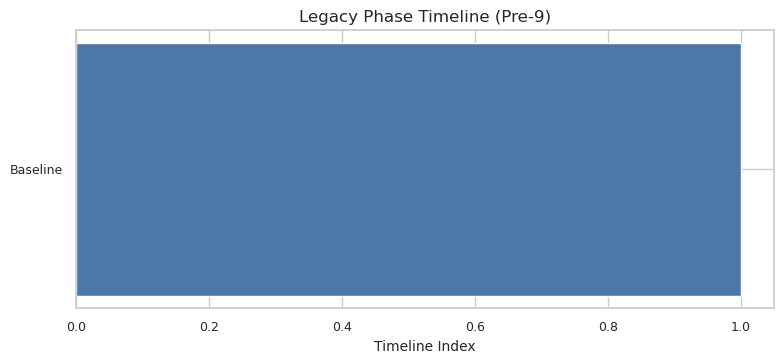

In [3]:
print("[설명] Legacy(pre9) 타임라인 요약을 출력해 wrap-up 맥락을 먼저 잡습니다.")
display(legacy)

if not legacy.empty:
    plt.figure(figsize=(8, 3.8))
    order = legacy["phase_label"].tolist()
    y = np.arange(len(order))
    plt.barh(y, np.arange(1, len(order)+1), color="#4c78a8")
    plt.yticks(y, order)
    plt.xlabel("Timeline Index")
    plt.title("Legacy Phase Timeline (Pre-9)")
    plt.tight_layout()
    plt.show()


[설명] Phase9는 concept 내부 세팅 비교가 핵심이므로 setting-level scatter를 먼저 봅니다.


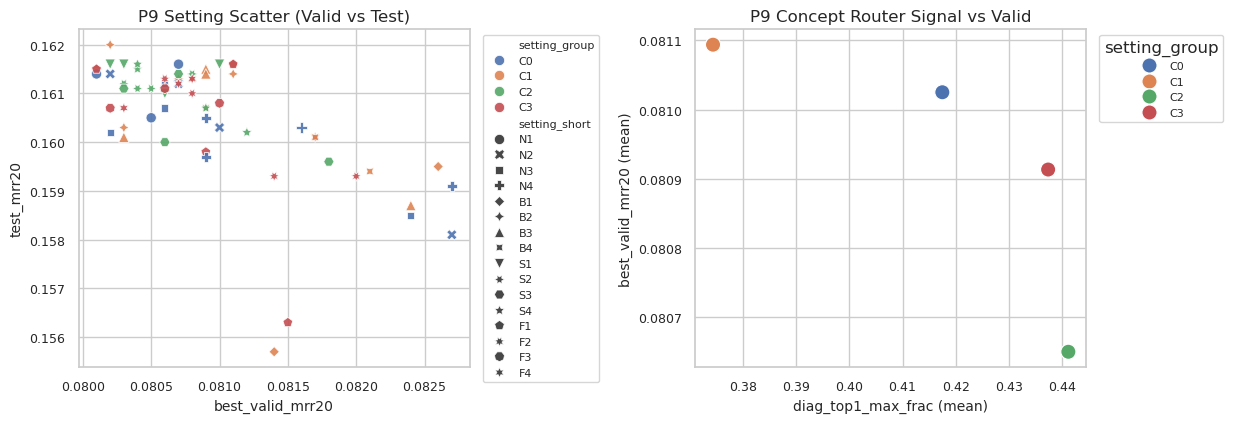

[설명] 좌측은 concept 내 세팅 분포, 우측은 concept 평균 router 신호(top1)와 valid 관계를 보여줍니다.


In [4]:
print("[설명] Phase9는 concept 내부 세팅 비교가 핵심이므로 setting-level scatter를 먼저 봅니다.")
p9 = wide[wide["source_phase"] == "P9"].copy()

if p9.empty:
    print("P9 rows are empty")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

    sns.scatterplot(
        data=p9,
        x="best_valid_mrr20",
        y="test_mrr20",
        hue="setting_group",
        style="setting_short" if "setting_short" in p9.columns else None,
        s=55,
        alpha=0.9,
        ax=axes[0],
    )
    axes[0].set_title("P9 Setting Scatter (Valid vs Test)")
    axes[0].set_xlabel("best_valid_mrr20")
    axes[0].set_ylabel("test_mrr20")
    leg = axes[0].get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((1.02, 1.0))
        leg._loc = 2

    agg = p9.groupby("setting_group", as_index=False).agg(
        valid_mean=("best_valid_mrr20", "mean"),
        test_mean=("test_mrr20", "mean"),
        top1_mean=("diag_top1_max_frac", "mean"),
        cv_mean=("diag_cv_usage", "mean"),
    )
    sns.scatterplot(data=agg, x="top1_mean", y="valid_mean", hue="setting_group", s=120, ax=axes[1])
    axes[1].set_title("P9 Concept Router Signal vs Valid")
    axes[1].set_xlabel("diag_top1_max_frac (mean)")
    axes[1].set_ylabel("best_valid_mrr20 (mean)")
    leg2 = axes[1].get_legend()
    if leg2 is not None:
        leg2.set_bbox_to_anchor((1.02, 1.0))
        leg2._loc = 2

    plt.tight_layout()
    plt.show()

    print("[설명] 좌측은 concept 내 세팅 분포, 우측은 concept 평균 router 신호(top1)와 valid 관계를 보여줍니다.")


[설명] P10~P13 wide는 축 비교보다 세팅 내부 비교에 집중해 phase별 top setting을 시각화합니다.


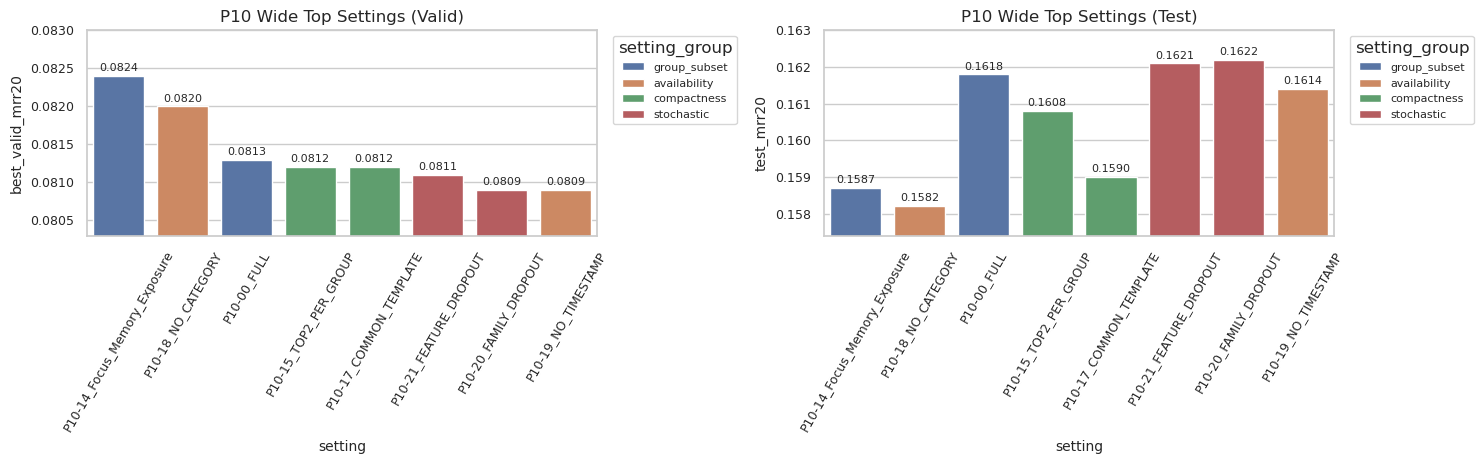

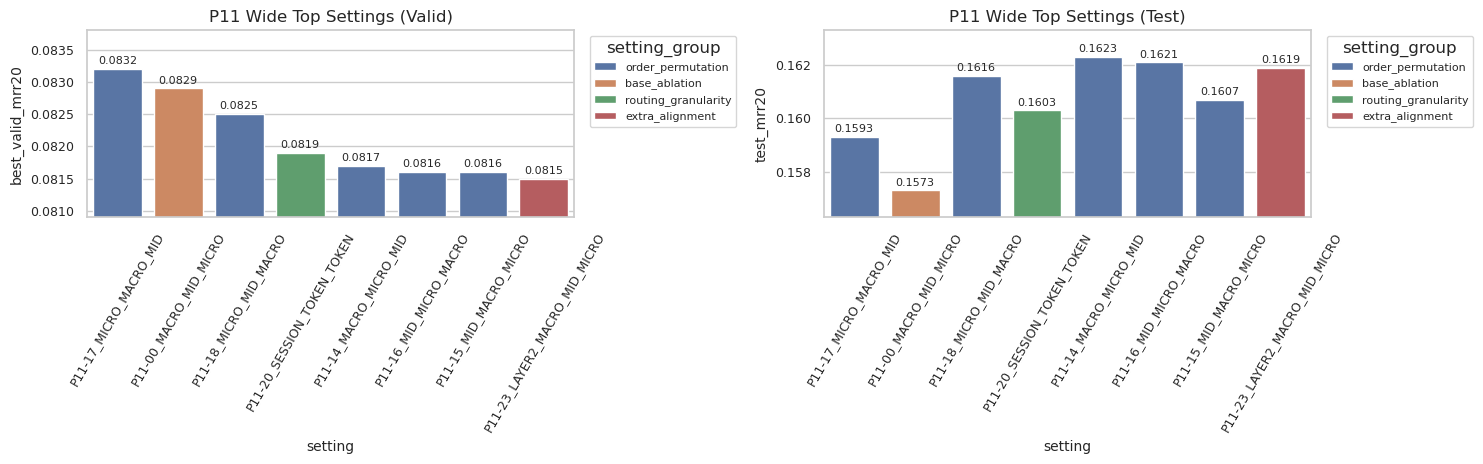

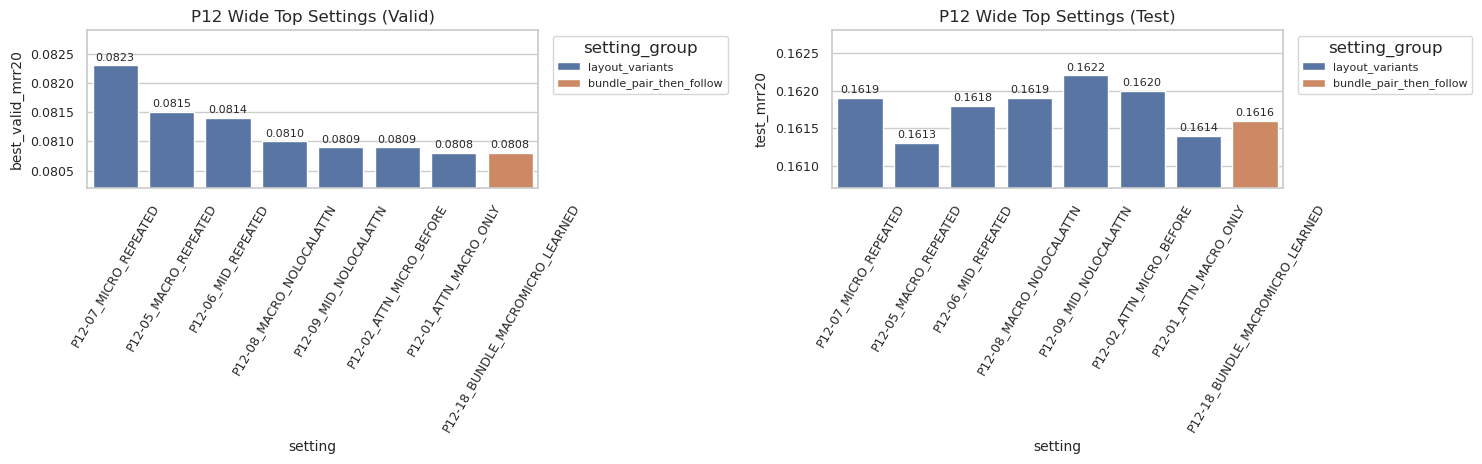

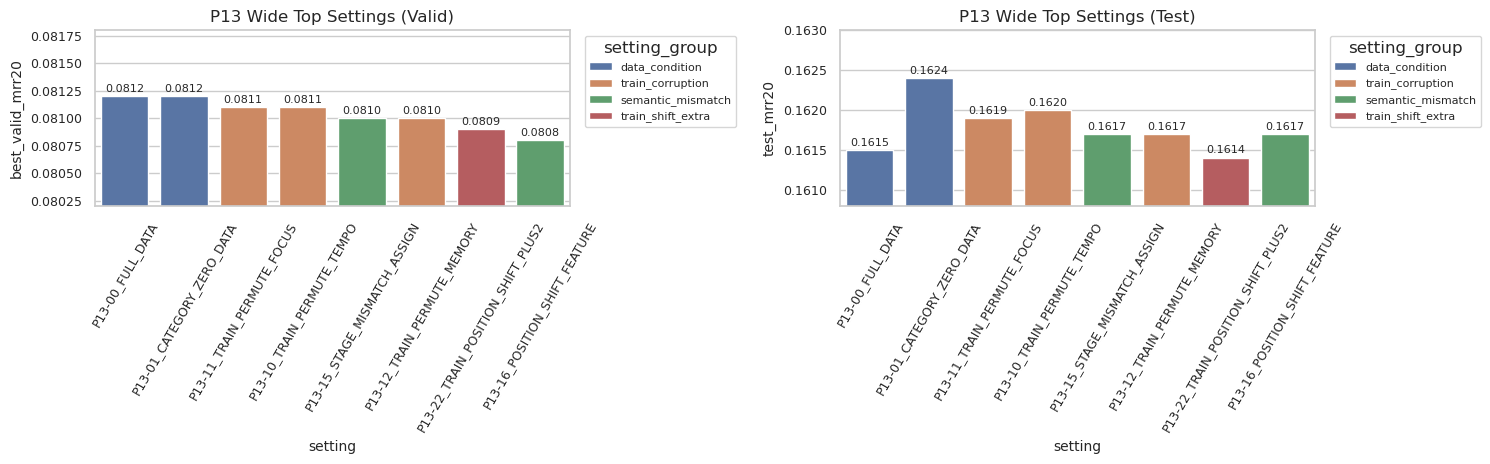

[설명] phase별로 valid/test winner가 달라지는 지점을 세팅 단위로 확인할 수 있습니다.


In [5]:
print("[설명] P10~P13 wide는 축 비교보다 세팅 내부 비교에 집중해 phase별 top setting을 시각화합니다.")

def add_bar_labels(ax, fmt="{:.4f}"):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.annotate(fmt.format(h), (p.get_x() + p.get_width() / 2.0, h),
                        ha="center", va="bottom", fontsize=8, xytext=(0, 2), textcoords="offset points")

def set_tight_ylim(ax, series, pad=0.0006):
    vals = pd.to_numeric(series, errors="coerce").dropna().values
    if vals.size == 0:
        return
    lo = float(vals.min())
    hi = float(vals.max())
    if np.isclose(lo, hi):
        ax.set_ylim(lo - pad, hi + pad)
    else:
        ax.set_ylim(lo - max((hi - lo) * 0.2, pad), hi + max((hi - lo) * 0.2, pad))

for phase in ["P10", "P11", "P12", "P13"]:
    sub = wide[(wide["source_phase"] == phase)].copy()
    if sub.empty:
        continue
    sub = sub.sort_values("best_valid_mrr20", ascending=False).head(8)
    sub["setting_plot"] = sub["setting_key"].fillna(sub["run_phase"]).astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

    sns.barplot(data=sub, x="setting_plot", y="best_valid_mrr20", hue="setting_group", dodge=False, ax=axes[0])
    axes[0].set_title(f"{phase} Wide Top Settings (Valid)")
    axes[0].set_xlabel("setting")
    axes[0].set_ylabel("best_valid_mrr20")
    axes[0].tick_params(axis="x", rotation=60)
    set_tight_ylim(axes[0], sub["best_valid_mrr20"])
    add_bar_labels(axes[0])
    leg = axes[0].get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((1.02, 1.0))
        leg._loc = 2

    sns.barplot(data=sub, x="setting_plot", y="test_mrr20", hue="setting_group", dodge=False, ax=axes[1])
    axes[1].set_title(f"{phase} Wide Top Settings (Test)")
    axes[1].set_xlabel("setting")
    axes[1].set_ylabel("test_mrr20")
    axes[1].tick_params(axis="x", rotation=60)
    set_tight_ylim(axes[1], sub["test_mrr20"])
    add_bar_labels(axes[1])
    leg2 = axes[1].get_legend()
    if leg2 is not None:
        leg2.set_bbox_to_anchor((1.02, 1.0))
        leg2._loc = 2

    plt.tight_layout()
    plt.show()

print("[설명] phase별로 valid/test winner가 달라지는 지점을 세팅 단위로 확인할 수 있습니다.")


[설명] verification는 mean-std 안정성 관점으로 봅니다. legend는 그래프 밖으로 배치합니다.


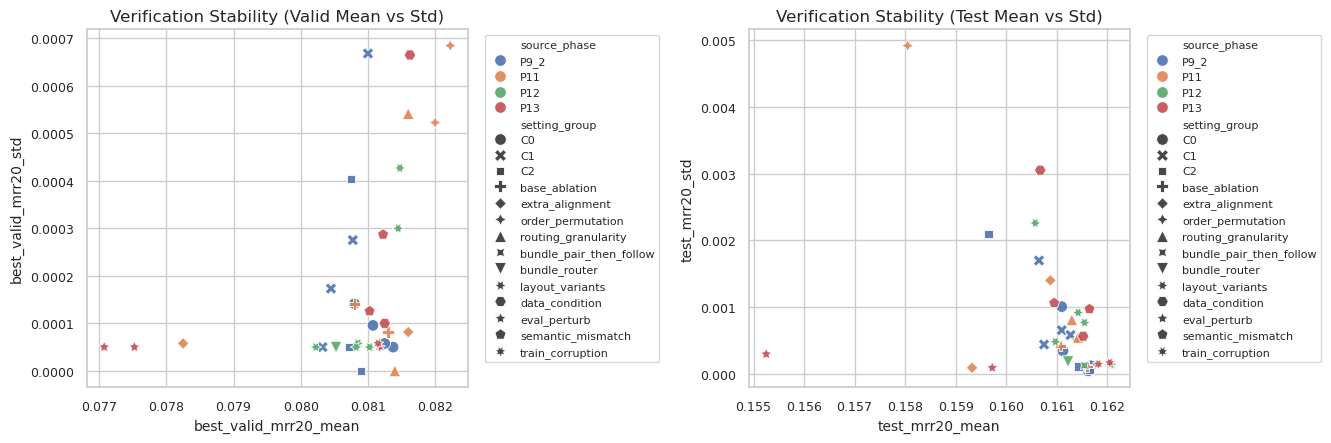

[설명] 평균이 높고 표준편차가 낮은 영역이 배포 관점에서 유리한 후보입니다.


In [6]:
print("[설명] verification는 mean-std 안정성 관점으로 봅니다. legend는 그래프 밖으로 배치합니다.")
main_phase = seed_stats[seed_stats["source_phase"].isin(["P9_2", "P11", "P12", "P13"])].copy()
main_phase = main_phase[main_phase["hparam_id"].astype(str).str.upper().eq("H3") | main_phase["source_phase"].eq("P9_2")]

if main_phase.empty:
    print("seed_stats for verification focus is empty")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

    sns.scatterplot(
        data=main_phase,
        x="best_valid_mrr20_mean",
        y="best_valid_mrr20_std",
        hue="source_phase",
        style="setting_group",
        s=70,
        alpha=0.9,
        ax=axes[0],
    )
    axes[0].set_title("Verification Stability (Valid Mean vs Std)")
    axes[0].set_xlabel("best_valid_mrr20_mean")
    axes[0].set_ylabel("best_valid_mrr20_std")
    leg = axes[0].get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((1.03, 1.0))
        leg._loc = 2

    sns.scatterplot(
        data=main_phase,
        x="test_mrr20_mean",
        y="test_mrr20_std",
        hue="source_phase",
        style="setting_group",
        s=70,
        alpha=0.9,
        ax=axes[1],
    )
    axes[1].set_title("Verification Stability (Test Mean vs Std)")
    axes[1].set_xlabel("test_mrr20_mean")
    axes[1].set_ylabel("test_mrr20_std")
    leg2 = axes[1].get_legend()
    if leg2 is not None:
        leg2.set_bbox_to_anchor((1.03, 1.0))
        leg2._loc = 2

    plt.tight_layout()
    plt.show()

print("[설명] 평균이 높고 표준편차가 낮은 영역이 배포 관점에서 유리한 후보입니다.")


[설명] test/cold/long metric은 스케일이 다르므로 분리된 plot으로 비교합니다.


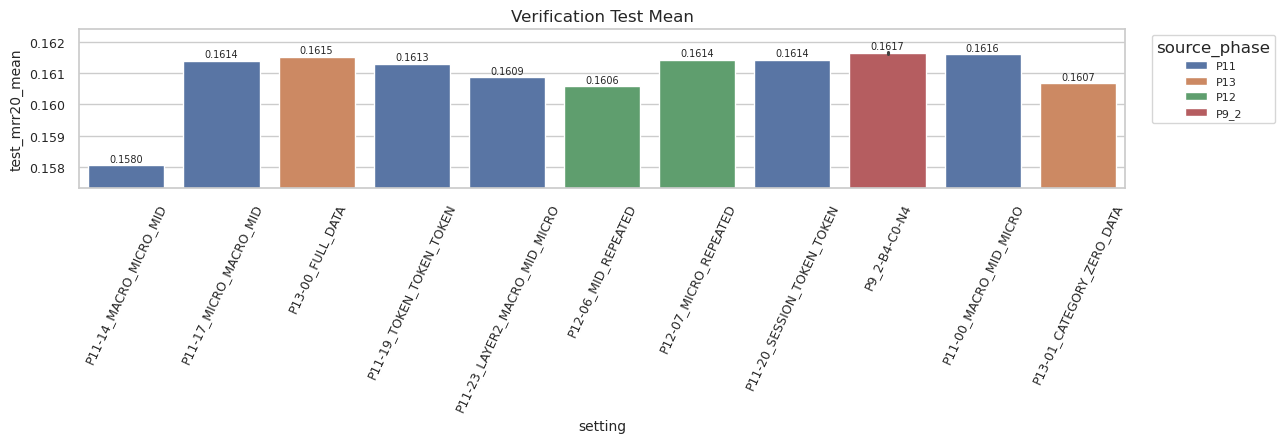

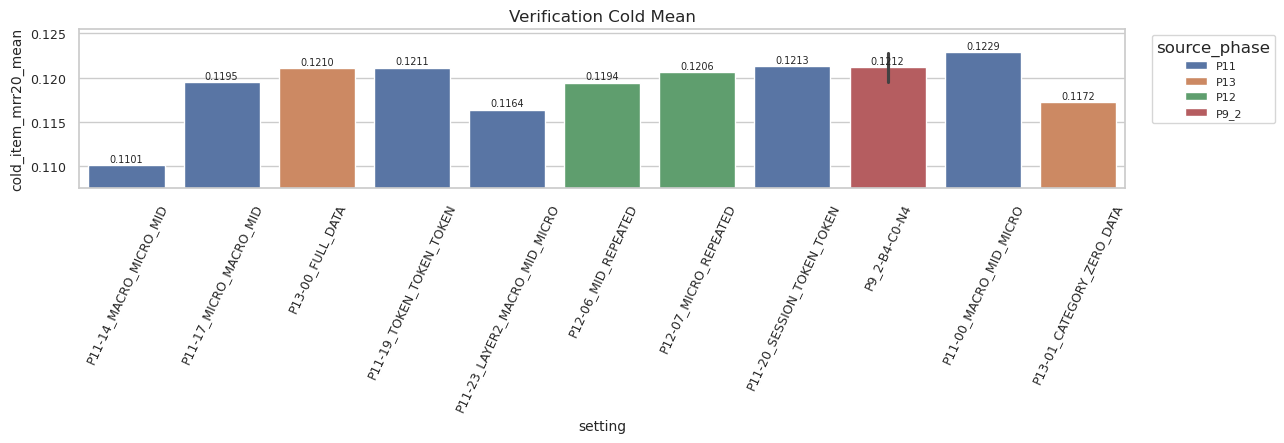

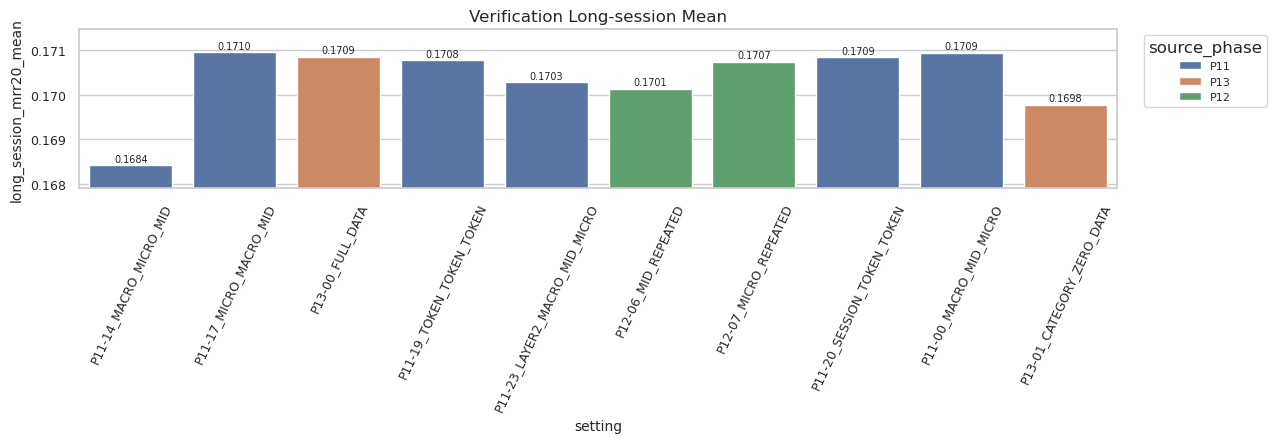

[설명] 분리 플롯으로 metric별 유리 세팅이 어떻게 달라지는지 명확히 볼 수 있습니다.


In [7]:
print("[설명] test/cold/long metric은 스케일이 다르므로 분리된 plot으로 비교합니다.")
focus = seed_stats[(seed_stats["source_phase"].isin(["P9_2", "P11", "P12", "P13"]))].copy()
focus = focus.sort_values("best_valid_mrr20_mean", ascending=False).head(12).copy()
focus["setting_plot"] = focus["setting_key"].fillna("na")

metric_specs = [
    ("test_mrr20_mean", "Verification Test Mean"),
    ("cold_item_mrr20_mean", "Verification Cold Mean"),
    ("long_session_mrr20_mean", "Verification Long-session Mean"),
]

for metric, title in metric_specs:
    if metric not in focus.columns:
        continue
    sub = focus[["setting_plot", metric, "source_phase"]].dropna()
    if sub.empty:
        continue
    plt.figure(figsize=(13, 4.6))
    ax = sns.barplot(data=sub, x="setting_plot", y=metric, hue="source_phase")
    ax.set_title(title)
    ax.set_xlabel("setting")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=65)

    vals = pd.to_numeric(sub[metric], errors="coerce").dropna()
    if len(vals) > 0:
        lo, hi = vals.min(), vals.max()
        pad = max((hi - lo) * 0.2, 0.0005)
        ax.set_ylim(lo - pad, hi + pad)

    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.annotate(f"{h:.4f}", (p.get_x() + p.get_width()/2, h),
                        ha="center", va="bottom", fontsize=7, xytext=(0, 1), textcoords="offset points")

    leg = ax.get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((1.02, 1.0))
        leg._loc = 2

    plt.tight_layout()
    plt.show()

print("[설명] 분리 플롯으로 metric별 유리 세팅이 어떻게 달라지는지 명확히 볼 수 있습니다.")


[설명] phase/metric별 diag 상관 히트맵으로 router 동작과 성능의 연결을 확인합니다.


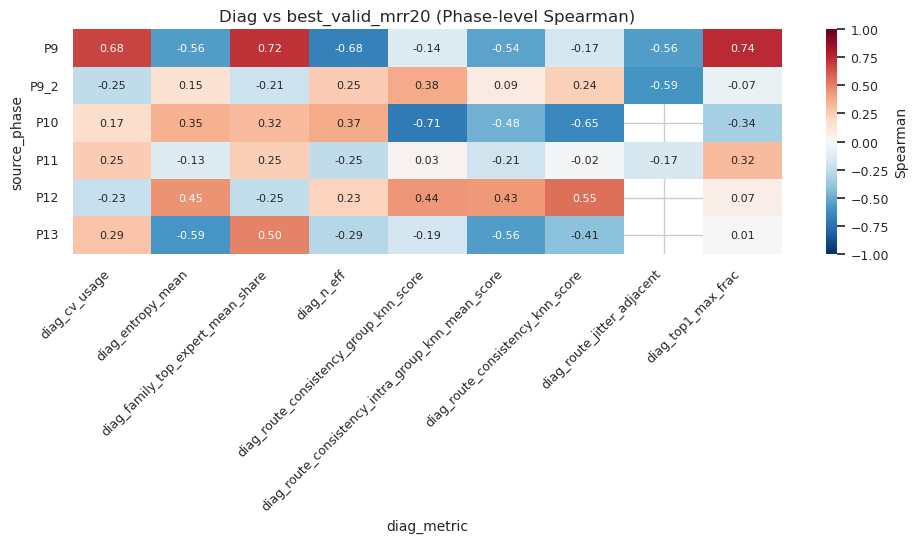

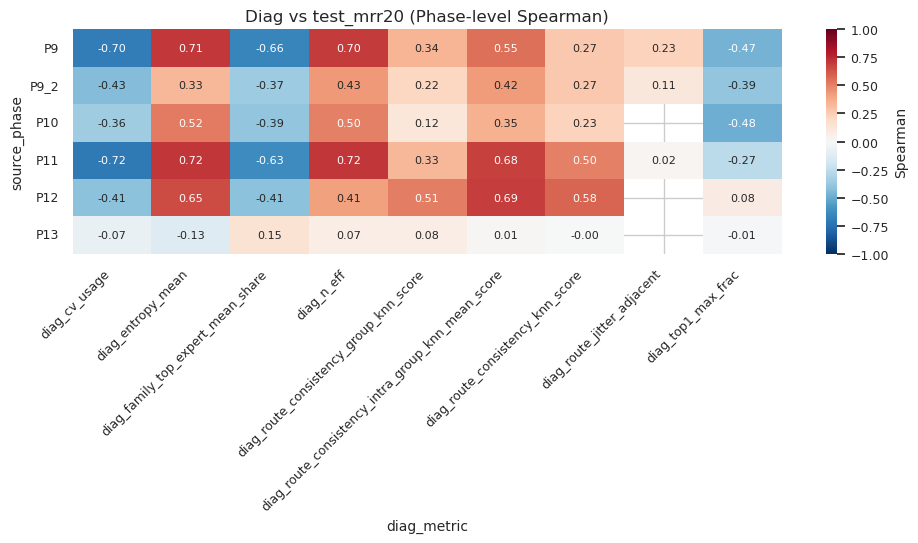

[설명] phase마다 sign/strength가 달라지는 metric이 있는지 확인해 주장 범위를 phase-conditioned로 제한할 수 있습니다.


In [8]:
print("[설명] phase/metric별 diag 상관 히트맵으로 router 동작과 성능의 연결을 확인합니다.")
sub = diag_corr[diag_corr["target_metric"].isin(["best_valid_mrr20", "test_mrr20"])].copy()
sub = sub[sub["n_pairs"] >= 8]

if sub.empty:
    print("diag_corr has no sufficient rows")
else:
    for target in ["best_valid_mrr20", "test_mrr20"]:
        ss = sub[sub["target_metric"] == target].copy()
        if ss.empty:
            continue
        # phase x diag metric using spearman over all splits (mean)
        pivot = ss.pivot_table(index="source_phase", columns="diag_metric", values="spearman", aggfunc="mean")
        pivot = pivot.reindex(index=[p for p in ["P9", "P9_2", "P10", "P11", "P12", "P13"] if p in pivot.index])

        w = min(16.0, max(9.5, 0.85 * len(pivot.columns) + 2.2))
        h = max(3.6, 0.7 * len(pivot.index) + 1.4)
        plt.figure(figsize=(w, h))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".2f",
            cmap="RdBu_r",
            center=0.0,
            vmin=-1.0,
            vmax=1.0,
            annot_kws={"size": 8},
            cbar_kws={"label": "Spearman"},
        )
        plt.title(f"Diag vs {target} (Phase-level Spearman)")
        plt.xlabel("diag_metric")
        plt.ylabel("source_phase")
        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

print("[설명] phase마다 sign/strength가 달라지는 metric이 있는지 확인해 주장 범위를 phase-conditioned로 제한할 수 있습니다.")


[설명] diag quantile trend로 단조/비단조 패턴을 확인합니다.


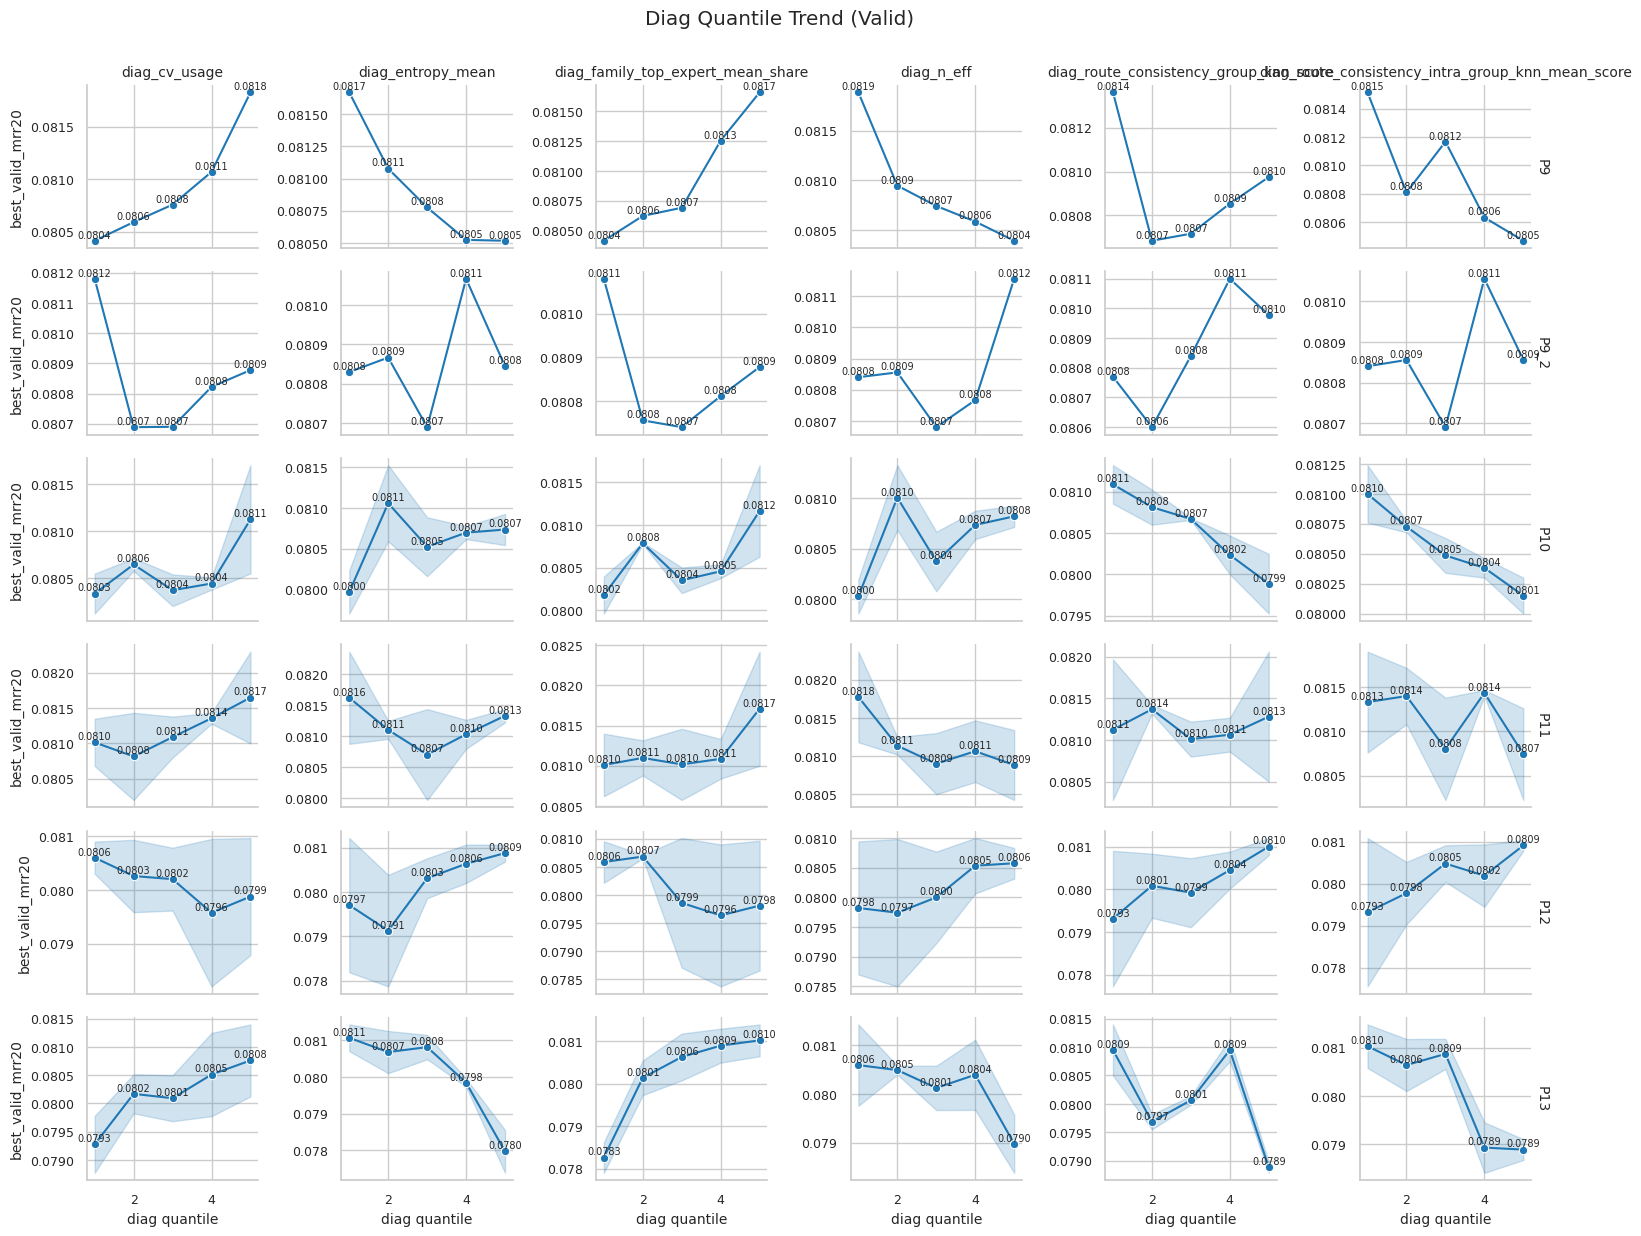

[설명] quantile 기반으로 어떤 diag 구간에서 성능이 올라가는지, 혹은 U-shape인지 확인할 수 있습니다.


In [9]:
print("[설명] diag quantile trend로 단조/비단조 패턴을 확인합니다.")
qsub = diag_q[(diag_q["target_metric"] == "best_valid_mrr20") & (diag_q["diag_quantile"].between(1, 5))].copy()

if qsub.empty:
    print("diag_quantile_profile is empty")
else:
    # choose representative metrics by coverage
    metric_order = (
        qsub.groupby("diag_metric")["n_pairs"].sum().sort_values(ascending=False).head(6).index.tolist()
    )
    qsub = qsub[qsub["diag_metric"].isin(metric_order)]

    g = sns.FacetGrid(
        qsub,
        row="source_phase",
        col="diag_metric",
        margin_titles=True,
        sharex=True,
        sharey=False,
        height=2.1,
        aspect=1.25,
    )
    g.map_dataframe(sns.lineplot, x="diag_quantile", y="target_mean", marker="o", color="#1f77b4")
    g.set_axis_labels("diag quantile", "best_valid_mrr20")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    for ax in g.axes.flat:
        if ax is None:
            continue
        for line in ax.lines:
            xd = line.get_xdata()
            yd = line.get_ydata()
            for x, y in zip(xd, yd):
                if np.isfinite(y):
                    ax.annotate(f"{y:.4f}", (x, y), fontsize=7, xytext=(0, 2), textcoords="offset points", ha="center")
    plt.subplots_adjust(top=0.92)
    g.fig.suptitle("Diag Quantile Trend (Valid)")
    plt.show()

print("[설명] quantile 기반으로 어떤 diag 구간에서 성능이 올라가는지, 혹은 U-shape인지 확인할 수 있습니다.")


[설명] router stage scalar를 이용해 n_eff/cv/top1 분포를 phase별로 비교합니다.


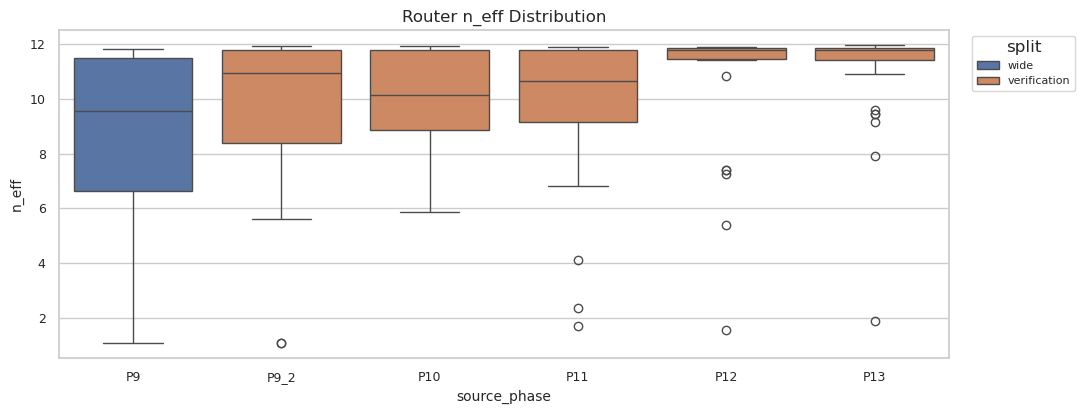

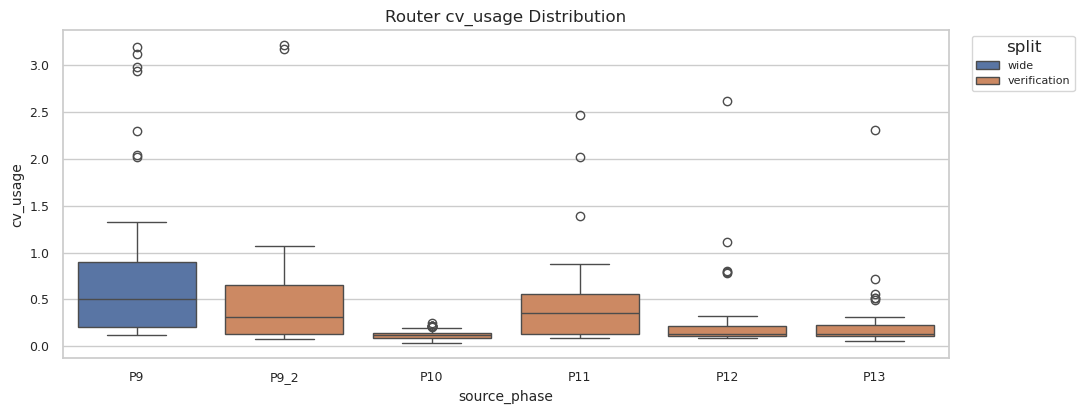

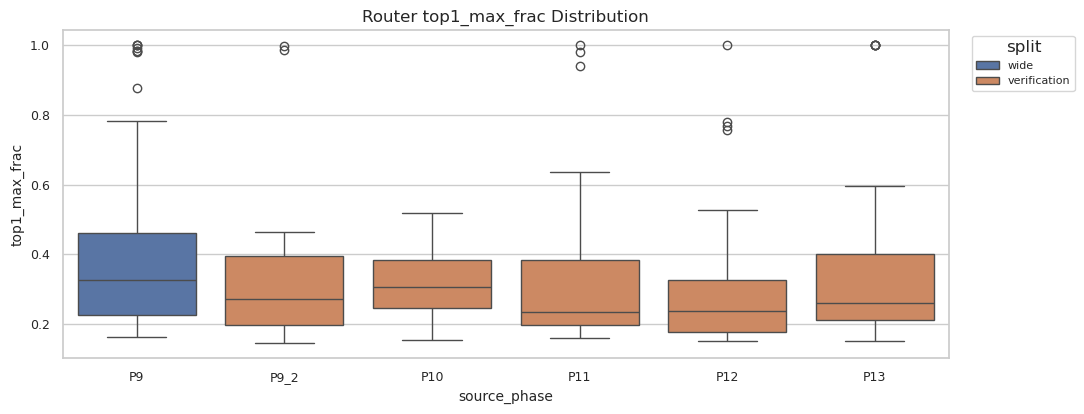

[설명] phase가 진행되며 router 분포가 균형/집중 방향 중 어디로 이동하는지 확인할 수 있습니다.


In [10]:
print("[설명] router stage scalar를 이용해 n_eff/cv/top1 분포를 phase별로 비교합니다.")
rs = router_stage.copy()
rs = rs[rs["source_phase"].isin(["P9", "P9_2", "P10", "P11", "P12", "P13"])]

metrics = [
    ("n_eff", "Router n_eff Distribution"),
    ("cv_usage", "Router cv_usage Distribution"),
    ("top1_max_frac", "Router top1_max_frac Distribution"),
]

for metric, title in metrics:
    if metric not in rs.columns:
        continue
    sub = rs[["source_phase", "split", metric]].dropna().copy()
    if sub.empty:
        continue
    plt.figure(figsize=(11, 4.3))
    ax = sns.boxplot(data=sub, x="source_phase", y=metric, hue="split")
    ax.set_title(title)
    ax.set_xlabel("source_phase")
    ax.set_ylabel(metric)
    leg = ax.get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((1.02, 1.0))
        leg._loc = 2
    plt.tight_layout()
    plt.show()

print("[설명] phase가 진행되며 router 분포가 균형/집중 방향 중 어디로 이동하는지 확인할 수 있습니다.")


[설명] router family heatmap으로 세팅별 feature-family expert 사용 패턴을 봅니다.


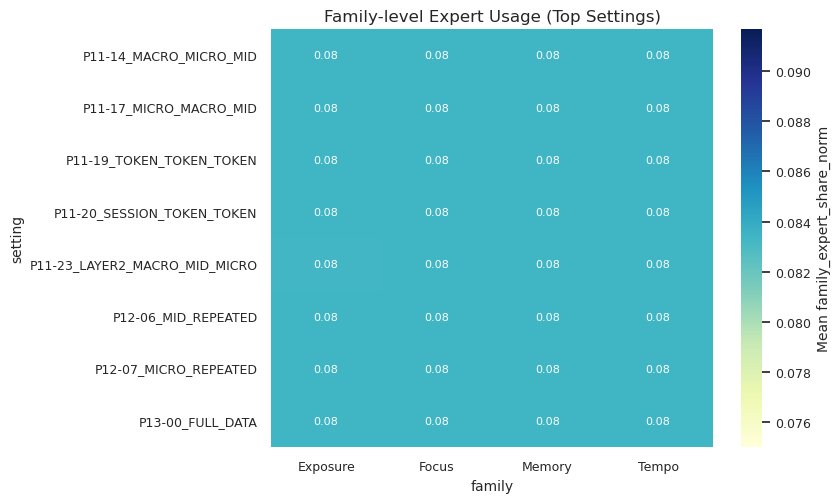

[설명] 어떤 세팅이 특정 family 사용을 강화/완화하는지 확인하고, 계획 의도와 연결할 수 있습니다.


In [11]:
print("[설명] router family heatmap으로 세팅별 feature-family expert 사용 패턴을 봅니다.")
rf = router_family.copy()
rf = rf[rf["source_phase"].isin(["P10", "P11", "P12", "P13"])].copy()

if rf.empty:
    print("router_family is empty")
else:
    top_settings = (
        rf.groupby("setting_key", as_index=False)["best_valid_mrr20"]
        .mean()
        .sort_values("best_valid_mrr20", ascending=False)
        .head(8)["setting_key"]
        .tolist()
    )
    sub = rf[rf["setting_key"].isin(top_settings)].copy()
    if not sub.empty:
        pivot = sub.pivot_table(
            index="setting_key",
            columns="family",
            values="family_expert_share_norm",
            aggfunc="mean",
        )
        plt.figure(figsize=(8.5, max(3.8, 0.45 * len(pivot.index) + 1.6)))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            annot_kws={"size": 8},
            cbar_kws={"label": "Mean family_expert_share_norm"},
        )
        plt.title("Family-level Expert Usage (Top Settings)")
        plt.xlabel("family")
        plt.ylabel("setting")
        plt.tight_layout()
        plt.show()

print("[설명] 어떤 세팅이 특정 family 사용을 강화/완화하는지 확인하고, 계획 의도와 연결할 수 있습니다.")


[설명] phase9~13 PCA/proxy scatter로 family-expert 분포 지형을 봅니다.


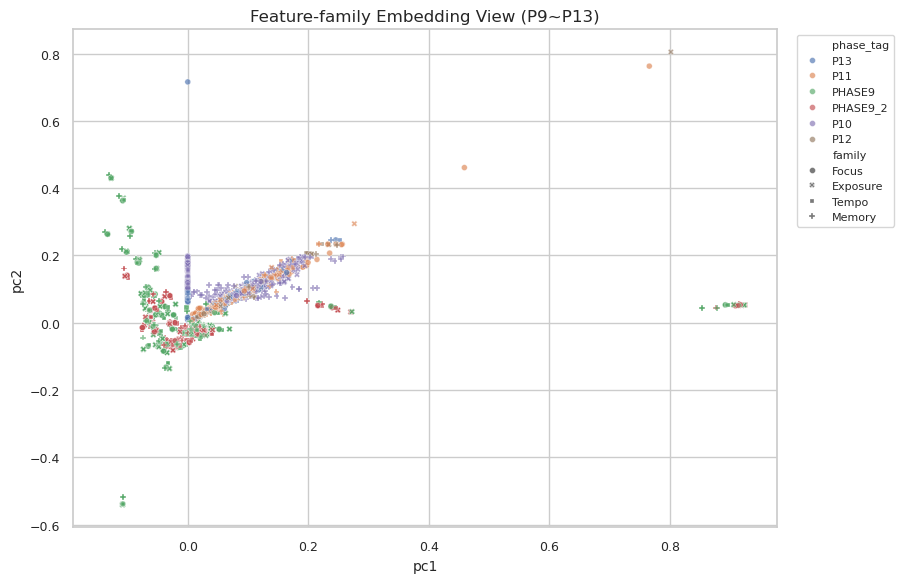

[설명] phase별 cluster 이동이 보이면 router가 family 표현을 다르게 사용하는 근거로 제시할 수 있습니다.


In [12]:
print("[설명] phase9~13 PCA/proxy scatter로 family-expert 분포 지형을 봅니다.")
fp = family_pca.copy()
fp = fp[fp["phase_tag"].isin(["phase9", "phase9_2", "p10", "p11", "p12", "p13"])].copy()

if fp.empty:
    print("family_pca_points_9_13 is empty")
else:
    # normalize phase tags
    fp["phase_tag"] = fp["phase_tag"].str.upper()
    fp["pc1"] = pd.to_numeric(fp["pc1"], errors="coerce")
    fp["pc2"] = pd.to_numeric(fp["pc2"], errors="coerce")
    sub = fp.dropna(subset=["pc1", "pc2"]).copy()

    if not sub.empty:
        plt.figure(figsize=(9.2, 6.0))
        ax = sns.scatterplot(
            data=sub.sample(min(5000, len(sub)), random_state=42),
            x="pc1",
            y="pc2",
            hue="phase_tag",
            style="family" if "family" in sub.columns else None,
            s=18,
            alpha=0.65,
        )
        ax.set_title("Feature-family Embedding View (P9~P13)")
        ax.set_xlabel("pc1")
        ax.set_ylabel("pc2")
        leg = ax.get_legend()
        if leg is not None:
            leg.set_bbox_to_anchor((1.02, 1.0))
            leg._loc = 2
        plt.tight_layout()
        plt.show()

print("[설명] phase별 cluster 이동이 보이면 router가 family 표현을 다르게 사용하는 근거로 제시할 수 있습니다.")


In [13]:
print("[설명] 최종 claim-evidence 맵을 출력합니다.")
cols = [
    c for c in [
        "source_phase", "setting_group", "observed_tag", "match_flag",
        "best_setting_key", "delta_best_valid_vs_anchor", "delta_best_test_vs_anchor", "paper_claim_template"
    ] if c in intent_map.columns
]

display(intent_map[cols].sort_values(["source_phase", "setting_group"]))

print("[결론] 이 노트북은 setting-level 비교 + diag/special 증거를 기반으로 논문 주장 문장을 연결하는 데 초점을 둡니다.")


[설명] 최종 claim-evidence 맵을 출력합니다.


,source_phase,setting_group,observed_tag,match_flag,best_setting_key,delta_best_valid_vs_anchor,delta_best_test_vs_anchor,paper_claim_template
4,P10,availability,matched_tradeoff,1,P10-18_NO_CATEGORY,0.000700,-0.003600,The framework remains functional even under pa...
5,P10,availability_plus,no_anchor,0,NaN,NaN,NaN,Severe multi-signal removal reveals the bounda...
6,P10,compactness,matched_tradeoff,1,P10-15_TOP2_PER_GROUP,-0.000100,-0.001000,Few representative signals per family are suff...
7,P10,compactness_plus,no_anchor,0,NaN,NaN,NaN,Even stricter compactness-plus settings preser...
8,P10,group_subset,matched_gain,1,P10-14_Focus_Memory_Exposure,0.001100,-0.003100,A compact subset of feature families can prese...
9,P10,stochastic,near_anchor,1,P10-21_FEATURE_DROPOUT,-0.000200,0.000300,Stochastic feature usage improves robustness w...
10,P11,base_ablation,matched_gain,1,P11-00_MACRO_MID_MICRO,0.000000,0.000000,Performance depends on temporal-horizon decomp...
11,P11,extra_alignment,matched_control_drop,1,P11-23_LAYER2_MACRO_MID_MICRO,-0.001400,0.004600,Improvements are not explained by generic dept...
12,P11,order_permutation,matched_gain,1,P11-17_MICRO_MACRO_MID,0.000300,0.002000,"Ordering influences routing behavior, supporti..."
13,P11,prepend_layer,partial_tradeoff,1,P11-07_LAYER_MACRO_MID_MICRO,-0.001800,0.004500,Stage decomposition contributes beyond simply ...


[결론] 이 노트북은 setting-level 비교 + diag/special 증거를 기반으로 논문 주장 문장을 연결하는 데 초점을 둡니다.
